In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy import stats
from itertools import combinations
from rdkit import Chem
from rdkit.Chem import Lipinski, Descriptors

In [2]:
# ── rcParams (точно як у вашому стилі) ────────────────────────────────────────
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = [
    'Times New Roman', 'Liberation Serif',
    'DejaVu Serif', 'Bitstream Vera Serif', 'serif'
]
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ── Шляхи до файлів ───────────────────────────────────────────────────────────
BASE = "../data/link_invent_outputs"

SCORED = {
    "Raw Prior":     f"{BASE}/scored_sampling_test_raw_prior_full_3.csv",
    "PROTAC Active": f"{BASE}/scored_sampling_test_protac_active_full_3.csv",
}
ADMET = {
    "Raw Prior":     f"{BASE}/admet_test_raw_prior_3.csv",
    "PROTAC Active": f"{BASE}/admet_test_protac_active_full_3.csv",
}

GEN_ORDER = ["Raw Prior", "PROTAC Active"]

# Відображувані назви на графіках (внутрішні ключі не змінюються)
GEN_LABELS = {
    "Raw Prior":     "Апріорна вибірка",
    "PROTAC Active": "RL: Біологічна активність",
}
PALETTE = {
    "Raw Prior":     "#2471A3",  
    "PROTAC Active": "#C1392B",
}

In [4]:
# ── Аналіз лінкера ────────────────────────────────────────────────────────────
def analyze_linker(linker_smi):
    if pd.isna(linker_smi):
        return None, None, None
    mol = Chem.MolFromSmiles(linker_smi)
    if not mol:
        return None, None, None
    length    = mol.GetNumHeavyAtoms()
    f_csp3    = Lipinski.FractionCSP3(mol)
    rot_bonds = Descriptors.NumRotatableBonds(mol)
    return length, f_csp3, rot_bonds

In [9]:
# ── Завантаження даних ────────────────────────────────────────────────────────
scored_dfs, admet_dfs = {}, {}
for name in GEN_ORDER:
    s = pd.read_csv(SCORED[name]).dropna(subset=["SMILES", "Active_Probability"])
    s["Generation"] = name
    s[["Linker_Length", "Linker_fCsp3", "Linker_RotBonds"]] = s["Linker"].apply(
        lambda x: pd.Series(analyze_linker(x))
    )
    scored_dfs[name] = s

    a = pd.read_csv(ADMET[name]).dropna(subset=["SMILES"])
    a["Generation"] = name
    admet_dfs[name] = a

df_scored = pd.concat(scored_dfs.values(), ignore_index=True)
df_admet  = pd.concat(admet_dfs.values(),  ignore_index=True)

# Категоріальний порядок для seaborn
df_scored["Generation"] = pd.Categorical(df_scored["Generation"], categories=GEN_ORDER, ordered=True)
df_admet["Generation"]  = pd.Categorical(df_admet["Generation"],  categories=GEN_ORDER, ordered=True)

METRICS = {
    "Active_Probability": {
        "df": df_scored,
        "label": "А) Ймовірність активності",
        "ylabel": "Ймовірність активності",
    },
    "molecular_weight": {
        "df": df_admet,
        "label": "A) Молекулярна маса (MW, Da)",
        "ylabel": "MW (Da)",
    },
    "logP": {
        "df": df_admet,
        "label": "Б) Ліпофільність (LogP)",
        "ylabel": "LogP",
    },
    "tpsa": {
        "df": df_admet,
        "label": "В) Полярна площа поверхні (TPSA, Å²)",
        "ylabel": "TPSA (Å²)",
    },
    "Caco2_Wang": {
        "df": df_admet,
        "label": "Г) Клітинна проникність (Caco-2, logPapp)",
        "ylabel": "Caco-2 (logPapp)",
    },
    "Linker_Length": {
        "df": df_scored,
        "label": "Б) Довжина лінкера",
        "ylabel": "Довжина лінкера (атоми)",
    },
    "Linker_fCsp3": {
        "df": df_scored,
        "label": "В) Частка sp³-вуглеців лінкера (fCsp3)",
        "ylabel": "fCsp3 лінкера",
    },
    "Linker_RotBonds": {
        "df": df_scored,
        "label": "Г) Кількість ротативних зв'язків лінкера",
        "ylabel": "Ротативні зв'язки лінкера",
    },
}

In [ ]:
import numpy as np
from scipy import stats


def cliffs_delta(a: np.ndarray, b: np.ndarray) -> tuple[float, str]:
    """
    Cliff's delta effect size for two independent samples.
    Returns (delta, magnitude_label).
    
    Interpretation (Romano et al., 2006):
        |d| < 0.147  → negligible
        |d| < 0.330  → small
        |d| < 0.474  → medium
        otherwise    → large
    """
    a, b = np.asarray(a), np.asarray(b)
    # Count all (a_i, b_j) pairs where a > b, a < b
    # Broadcasting: shape (len_a, len_b)
    matrix = np.sign(a[:, None] - b[None, :])
    delta = matrix.mean()

    magnitude = (
        "negligible" if abs(delta) < 0.147 else
        "small"      if abs(delta) < 0.330 else
        "medium"     if abs(delta) < 0.474 else
        "large"
    )
    return float(delta), magnitude


def perform_mann_whitney(groups: dict) -> dict:
    keys = list(groups.keys())
    a_name, b_name = keys[0], keys[1]

    group_a = groups[a_name].dropna().to_numpy()
    group_b = groups[b_name].dropna().to_numpy()

    u_stat, p_val = stats.mannwhitneyu(group_a, group_b, alternative="two-sided")
    delta, magnitude = cliffs_delta(group_a, group_b)

    def get_stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"

    return {
        "pairs": [
            {
                "pair":      (a_name, b_name),
                "p_raw":     p_val,
                "stars":     get_stars(p_val),
                "u_stat":    u_stat,
                "cliffs_d":  delta,
                "magnitude": magnitude,
                "n_a":       len(group_a),
                "n_b":       len(group_b),
            }
        ]
    }


# ── Main loop ─────────────────────────────────────────────────────────────────
stat_results = {}

for col, cfg in METRICS.items():
    groups = {
        g: cfg["df"].loc[cfg["df"]["Generation"] == g, col]
        for g in GEN_ORDER if g in ["Raw Prior", "PROTAC Active"]
    }

    res = perform_mann_whitney(groups)
    stat_results[col] = res

    r = res["pairs"][0]
    print(f"\n{'═' * 60}")
    print(f"  {cfg['label'].replace(chr(10), ' ')}")
    print(f"  Mann–Whitney U  (n={r['n_a']} vs n={r['n_b']})")
    print(f"  U = {r['u_stat']:.0f},  p = {r['p_raw']:.2e}  {r['stars']}")
    print(f"  Cliff's Δ = {r['cliffs_d']:+.3f}  [{r['magnitude']}]")


═══════════════════════════════════════════════════════
  А) Ймовірність активності
  Mann–Whitney U test: Raw Prior vs PROTAC Active
  p-value = 3.97e-116  (***)

═══════════════════════════════════════════════════════
  A) Молекулярна маса (MW, Da)
  Mann–Whitney U test: Raw Prior vs PROTAC Active
  p-value = 5.01e-26  (***)

═══════════════════════════════════════════════════════
  Б) Ліпофільність (LogP)
  Mann–Whitney U test: Raw Prior vs PROTAC Active
  p-value = 1.26e-01  (ns)

═══════════════════════════════════════════════════════
  В) Полярна площа поверхні (TPSA, Å²)
  Mann–Whitney U test: Raw Prior vs PROTAC Active
  p-value = 1.16e-36  (***)

═══════════════════════════════════════════════════════
  Г) Клітинна проникність (Caco-2, logPapp)
  Mann–Whitney U test: Raw Prior vs PROTAC Active
  p-value = 5.60e-29  (***)

═══════════════════════════════════════════════════════
  Б) Довжина лінкера
  Mann–Whitney U test: Raw Prior vs PROTAC Active
  p-value = 5.62e-16  (***)



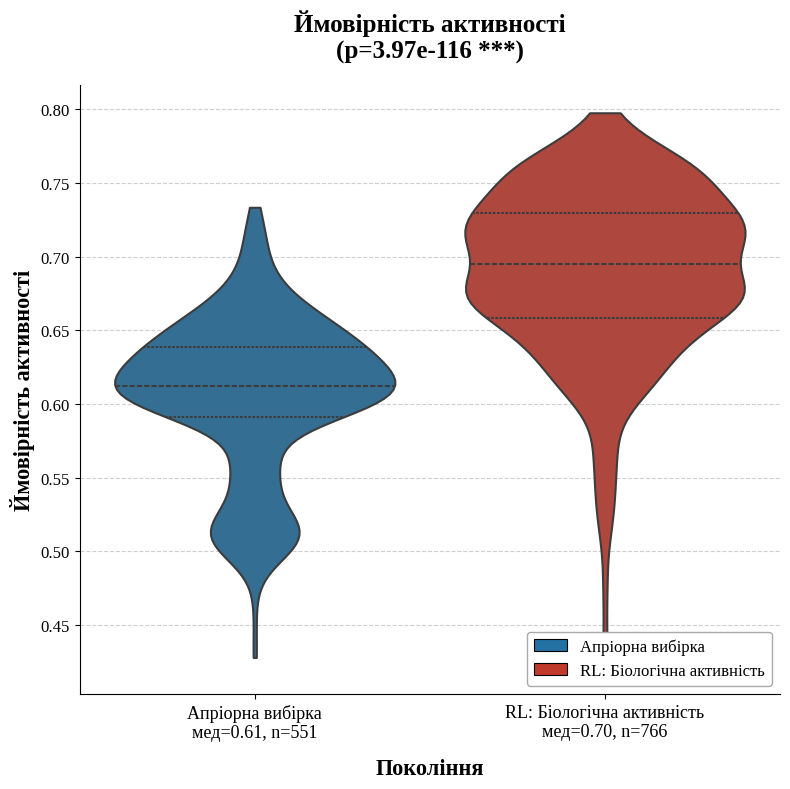

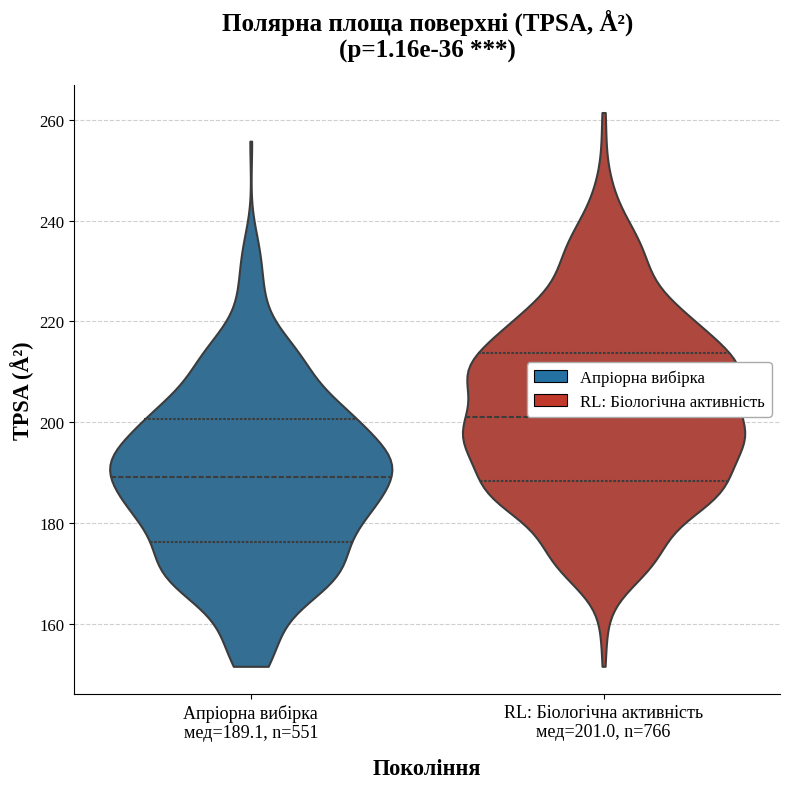

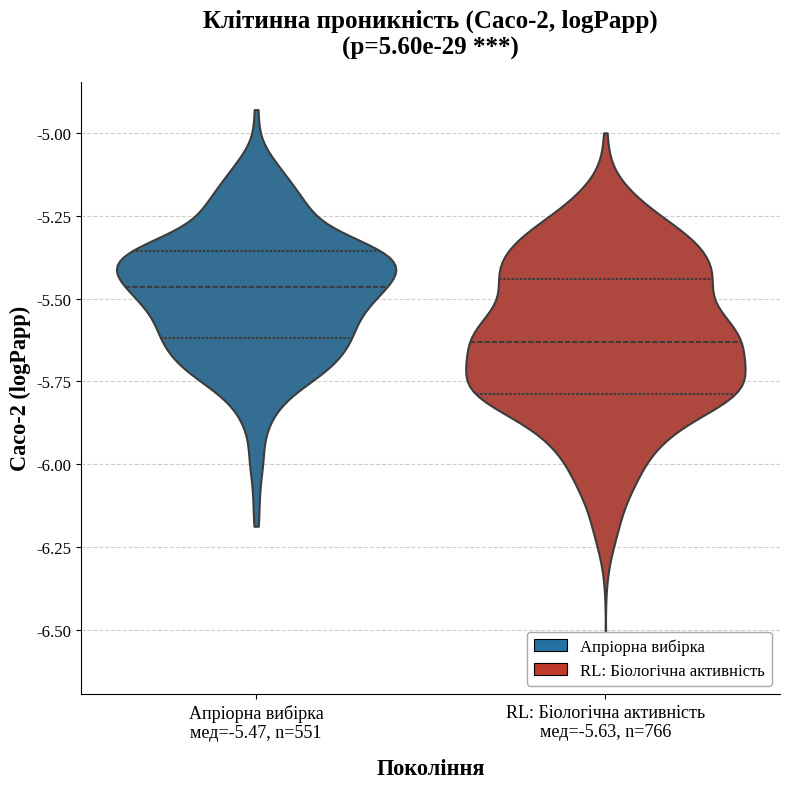

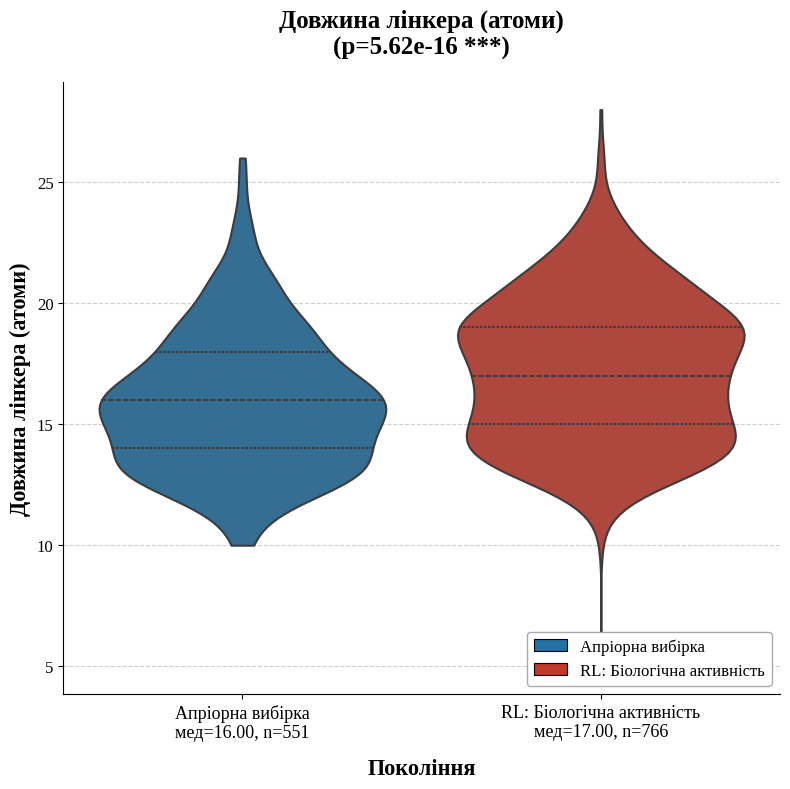

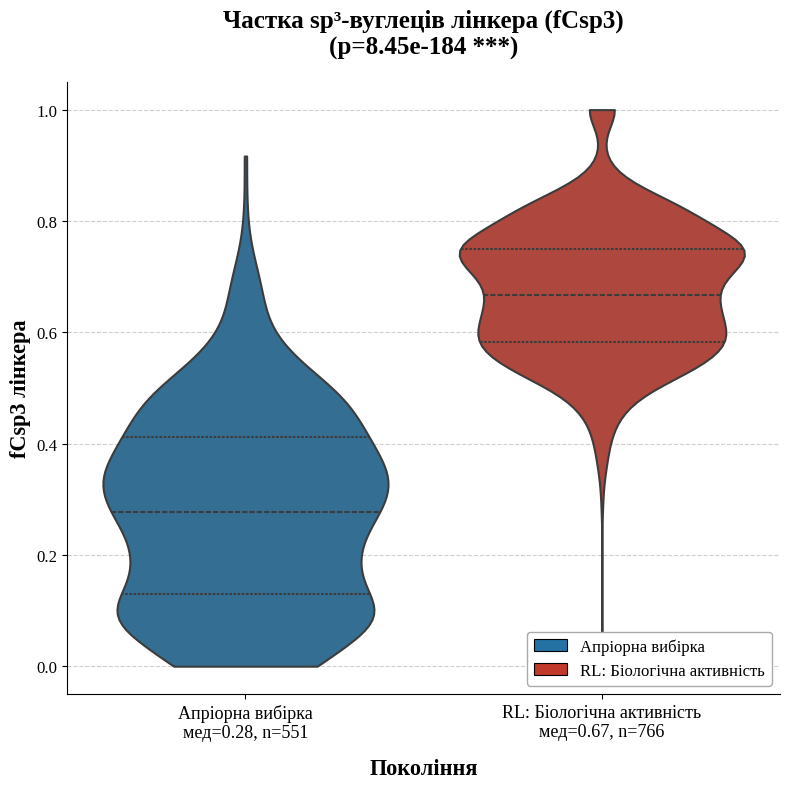

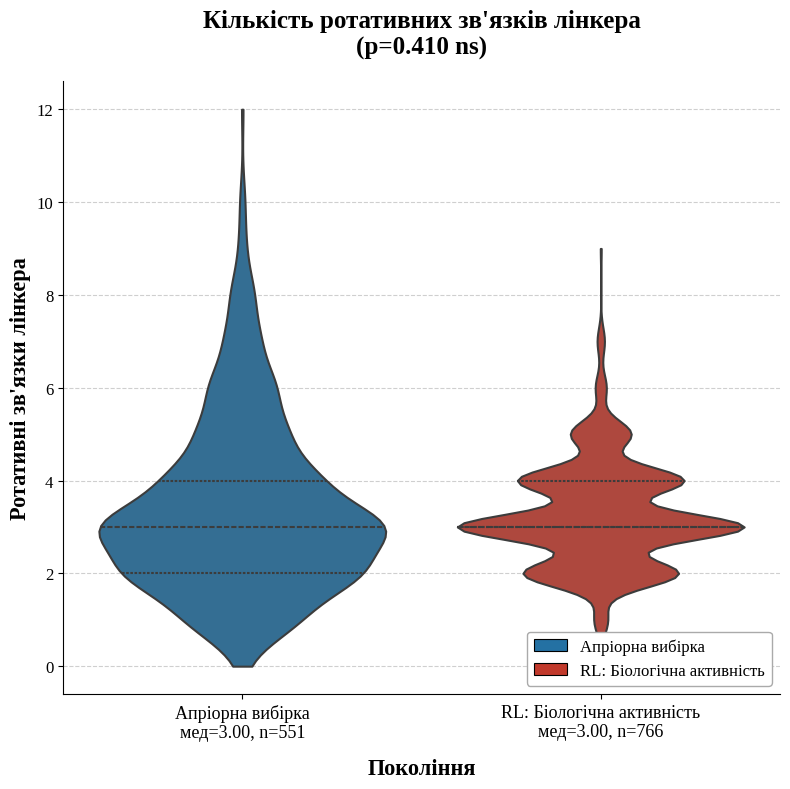

In [10]:
# Updated Constants for Brackets (Only one pair remains)
PAIR_XPOS = {
    ("Raw Prior", "PROTAC Active"): (0, 1),
}
BRACKET_LEVEL = {
    ("Raw Prior", "PROTAC Active"): 0,
}

# ── Індивідуальні налаштування для кожного графіка ───────────────────────────
PLOT_CFG = {
    "Active_Probability": {
        # Легенда: верхній лівий кут — там є вільний простір (Raw Prior йде вниз)
        "legend_loc":  "lower right",
        "legend_bbox": None,
        # Відступ зверху для дужок (у частках від діапазону даних)
        "top_pad":  0.28,
        "filename": "violin_active_probability.png",
    },
    "tpsa": {
        "legend_loc":  "center right",
        "legend_bbox": None,
        "top_pad":  0.30,
        "filename": "violin_tpsa.png",
    },
    "Caco2_Wang": {
        "legend_loc":  "lower right",
        "legend_bbox": None,
        "top_pad":  0.30,
        "filename": "violin_caco2_wang.png",
    },
    "Linker_Length": {
        "legend_loc":  "lower right",
        "legend_bbox": None,
        "top_pad":  0.18,
        "filename": "violin_linker_length.png",
    },
    "Linker_fCsp3": {
        "legend_loc":  "lower right",
        "legend_bbox": None,
        "top_pad":  0.18,
        "filename": "violin_linker_fcsp3.png",
    },
    "Linker_RotBonds": {
        "legend_loc":  "lower right",
        "legend_bbox": None,
        "top_pad":  0.18,
        "filename": "violin_linker_rotbonds.png",
    },
}

# ── Функція побудови одного графіка ───────────────────────────────────────────
def plot_single_violin(col, metric_cfg, plot_cfg, stat_res):
    # 1. Filter data to the two groups
    df_plot = metric_cfg["df"][metric_cfg["df"]["Generation"].isin(GEN_ORDER)].copy()
    n_by_gen = df_plot.groupby("Generation", observed=True)[col].count()

    # 2. Extract stats for the title
    # We grab the first (and only) pair result
    stats_info = stat_res["pairs"][0]
    p_val = stats_info["p_raw"]
    stars = stats_info["stars"]
    
    # Format the p-value for the title
    p_text = f"p={p_val:.2e}" if p_val < 0.001 else f"p={p_val:.3f}"
    full_title = f"{metric_cfg['label']}\n({p_text} {stars})"

    fig, ax = plt.subplots(figsize=(8, 8))

    # ── Violin ────────────────────────────────────────────────────────────────
    sns.violinplot(
        x="Generation", y=col,
        data=df_plot, order=GEN_ORDER,
        palette=PALETTE, hue="Generation",
        legend=False, cut=0,
        inner="quartile", linewidth=1.5,
        density_norm="width", ax=ax,
    )

    # ── Tick Labels ──────────────────────────────────────────────────────────
    tick_labels = []
    for gen in GEN_ORDER:
        arr = df_plot.loc[df_plot["Generation"] == gen, col].dropna()
        med = np.median(arr)
        n = n_by_gen[gen]
        fmt = ".2f" if col != "tpsa" else ".1f"
        tick_labels.append(f"{GEN_LABELS[gen]}\nмед={med:{fmt}}, n={n:,}")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(tick_labels, fontsize=13, fontfamily="serif")

    # ── Formatting ────────────────────────────────────────────────────────────
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    
    # Set the title with the p-value included
    ax.set_title(full_title, fontsize=18, fontweight="bold", pad=20)
    
    ax.set_xlabel("Покоління", fontsize=16, fontweight="bold", labelpad=12)
    ax.set_ylabel(metric_cfg["ylabel"], fontsize=16, fontweight="bold")
    ax.tick_params(axis="y", labelsize=12)

    # ── Legend ───────────────────────────────────────────────────────────────
    legend_patches = [
        patches.Patch(facecolor=PALETTE[g], edgecolor="black",
                      linewidth=0.8, label=GEN_LABELS[g])
        for g in GEN_ORDER
    ]
    ax.legend(
        handles=legend_patches,
        loc=plot_cfg["legend_loc"],
        prop={"size": 12, "family": "serif"},
        framealpha=1.0, edgecolor="#aaaaaa"
    )

    plt.tight_layout()
    plt.savefig(plot_cfg["filename"], dpi=400, bbox_inches="tight")
    plt.show()

# ── Генерація графіків ────────────────────────────────────────────────────────
for col, metric_cfg in METRICS.items():
    plot_single_violin(col, metric_cfg, PLOT_CFG[col], stat_results[col])

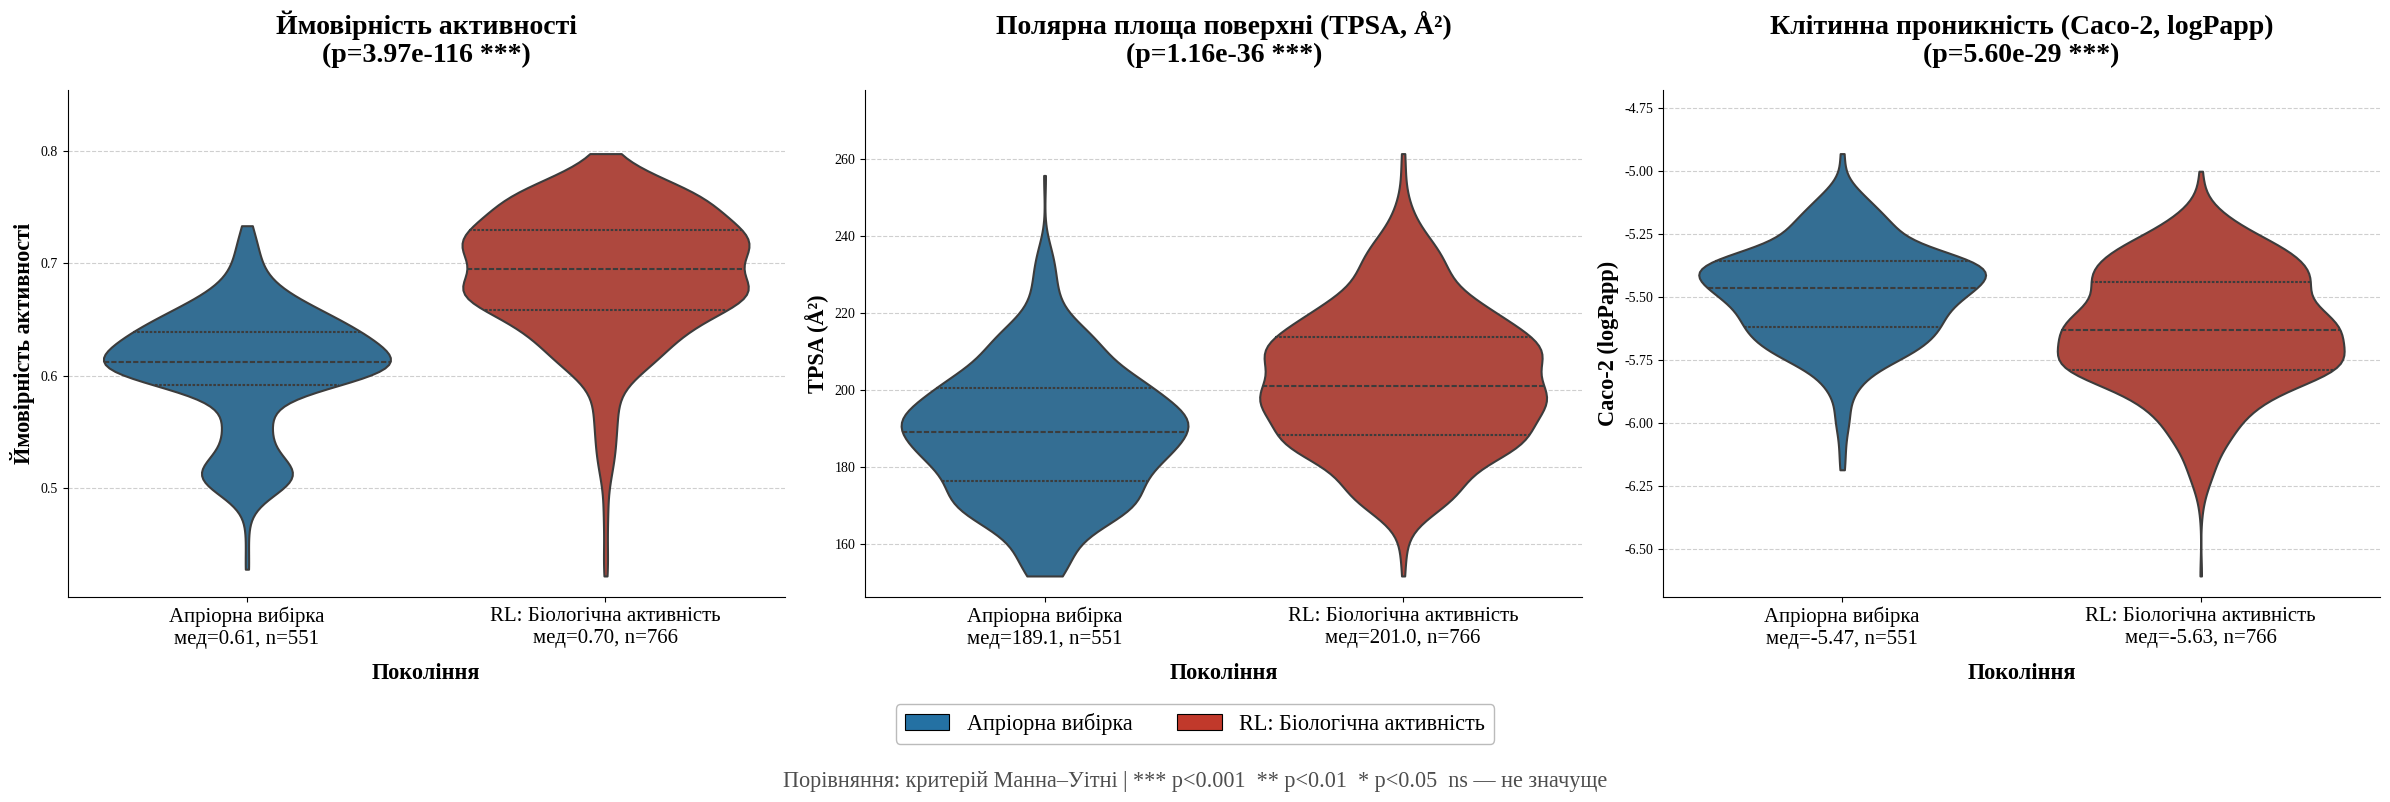

Combined plot saved as: combined_activity_tpsa_caco2.png


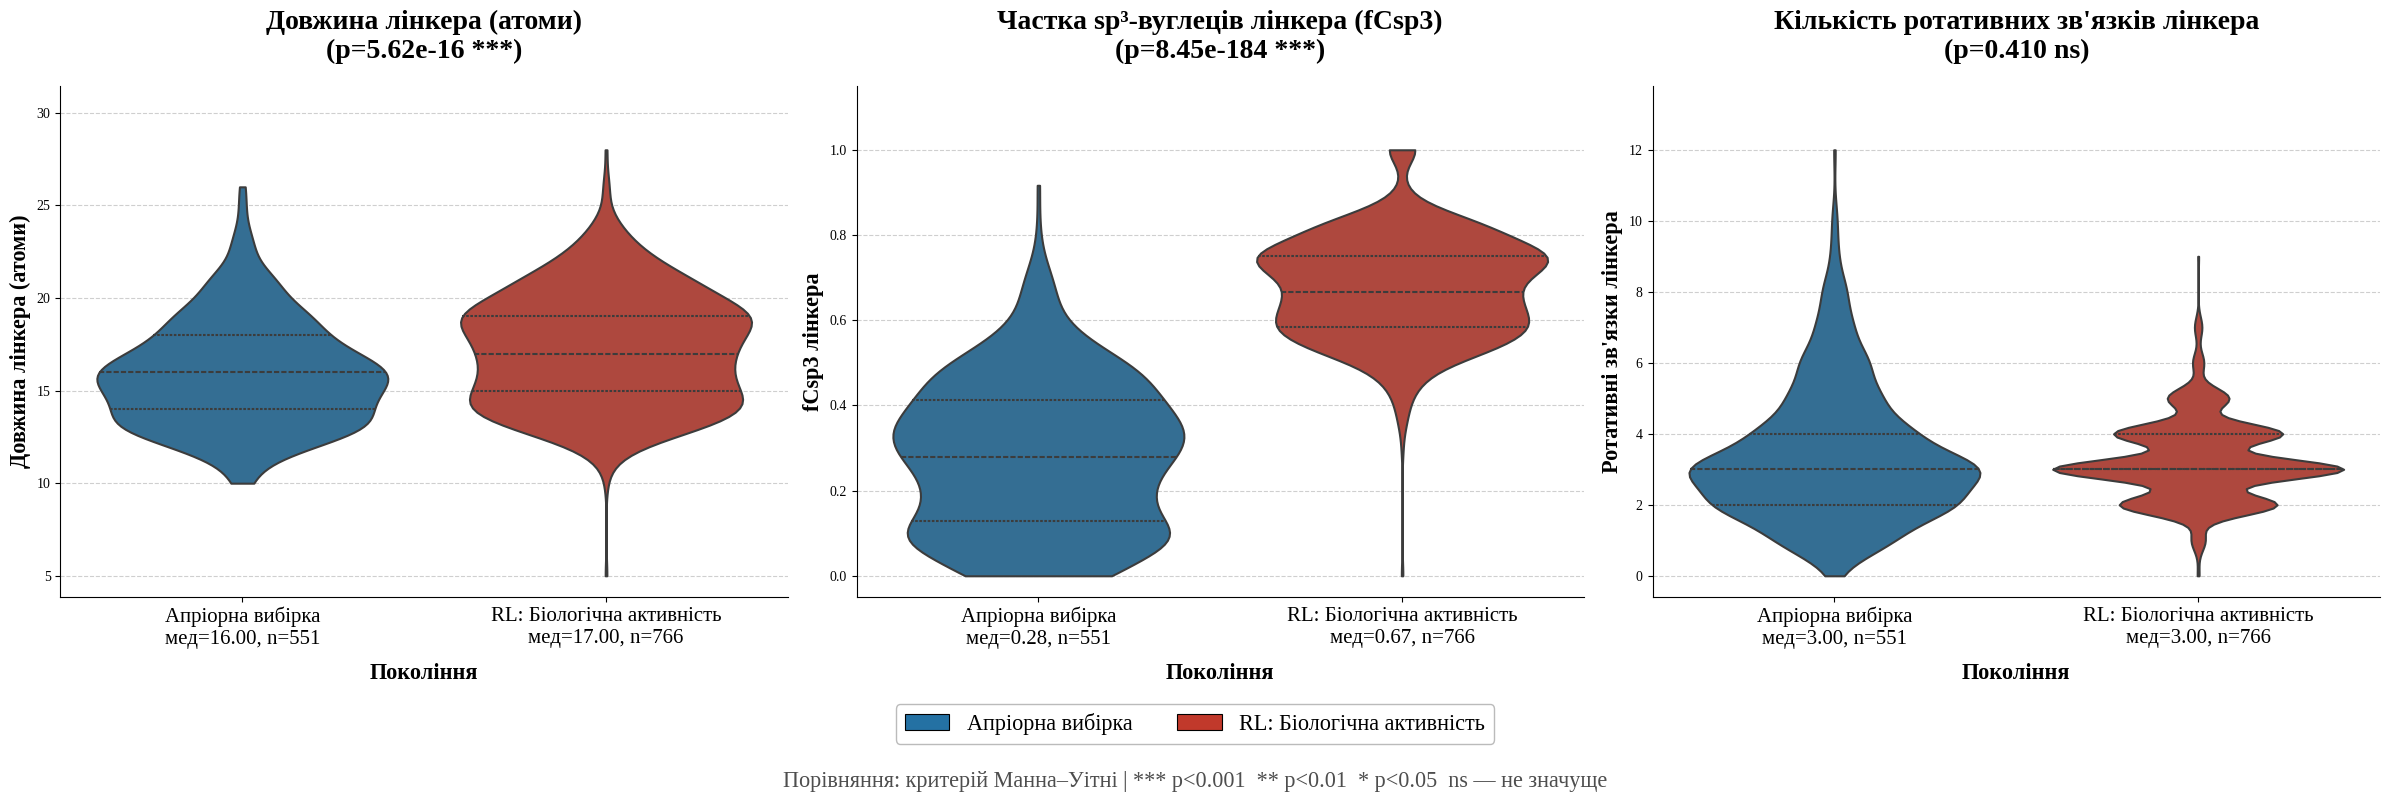

Combined plot saved as: combined_linker_length_fcsp3_rotbonds.png


In [22]:
# ── Налаштування груп ────────────────────────────────────────────────────────
GROUPS = [
    {
        "cols": ["Active_Probability", "tpsa", "Caco2_Wang"],
        "filename": "combined_activity_tpsa_caco2.png"
    },
    {
        "cols": ["Linker_Length", "Linker_fCsp3", "Linker_RotBonds"],
        "filename": "combined_linker_length_fcsp3_rotbonds.png"
    }
]

# ── Функція побудови комбінованого графіка (1 рядок, 3 колонки) ───────────────
def plot_combined_violins(cols, filename, METRICS, PLOT_CFG, stat_results):
    # Set GEN_ORDER if not already defined globally as just these two
    current_gen_order = ["Raw Prior", "PROTAC Active"]
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 8)) 
    
    legend_patches = [
        patches.Patch(facecolor=PALETTE[g], edgecolor="black", linewidth=0.8, label=GEN_LABELS[g])
        for g in current_gen_order
    ]

    for idx, col in enumerate(cols):
        ax = axes[idx]
        metric_cfg = METRICS[col]
        stat_res = stat_results[col]
        
        # 1. Filter data to only include the relevant groups
        df_plot = metric_cfg["df"][metric_cfg["df"]["Generation"].isin(current_gen_order)].copy()
        n_by_gen = df_plot.groupby("Generation", observed=True)[col].count()
        
        # 2. Extract Statistics for Title
        # Assumes stat_results[col]['pairs'][0] contains the Mann-Whitney result
        pair_stat = stat_res["pairs"][0]
        p_val = pair_stat["p_raw"]
        stars = pair_stat["stars"]
        p_text = f"p={p_val:.2e}" if p_val < 0.001 else f"p={p_val:.3f}"
        
        # 3. Violin Plot
        sns.violinplot(
            x="Generation", y=col, data=df_plot, order=current_gen_order,
            palette=PALETTE, hue="Generation", legend=False,
            cut=0, inner="quartile", linewidth=1.5, density_norm="width", ax=ax
        )

        # 4. Tick Labels (Medians and N)
        tick_labels = []
        for gen in current_gen_order:
            arr = df_plot.loc[df_plot["Generation"] == gen, col].dropna()
            med = np.median(arr)
            n = n_by_gen[gen]
            fmt = ".2f" if col.lower() != "tpsa" else ".1f"
            tick_labels.append(f"{GEN_LABELS[gen]}\nмед={med:{fmt}}, n={n:,}")

        ax.set_xticks([0, 1])
        ax.set_xticklabels(tick_labels, fontsize=15, fontfamily="serif")
        
        # 5. Styling & Title
        ax.set_title(f"{metric_cfg['label']}\n({p_text} {stars})", 
                     fontsize=20, fontweight="bold", pad=20)
        ax.set_xlabel("Покоління", fontsize=16, fontweight="bold", labelpad=10)
        ax.set_ylabel(metric_cfg["ylabel"], fontsize=16, fontweight="bold")
        
        ax.set_axisbelow(True)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.spines[["top", "right"]].set_visible(False)

        # 6. Y-axis Padding (No brackets needed, but add space for title)
        data_max = df_plot[col].max()
        data_min = df_plot[col].min()
        range_val = data_max - data_min
        ax.set_ylim(bottom=data_min - range_val * 0.05, top=data_max + range_val * 0.15)

    # ── Shared Legend ──
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.05), 
        ncol=2,
        prop={'size': 16, 'family': 'serif'},
        frameon=True,
        edgecolor="#aaaaaa"
    )

    # ── Footer Statistics ──
    fig.text(
        0.5, 0.01,
        "Порівняння: критерій Манна–Уітні | *** p<0.001  ** p<0.01  * p<0.05  ns — не значуще",
        ha="center", fontsize=16, fontfamily="serif", color="#4E4E4E"
    )

    plt.tight_layout(rect=[0, 0.12, 1, 1]) 
    plt.savefig(filename, dpi=400, bbox_inches="tight")
    plt.show()
    print(f"Combined plot saved as: {filename}")


for group in GROUPS:
    plot_combined_violins(
        cols=group["cols"],
        filename=group["filename"],
        METRICS=METRICS,
        PLOT_CFG=PLOT_CFG,
        stat_results=stat_results
    ) 

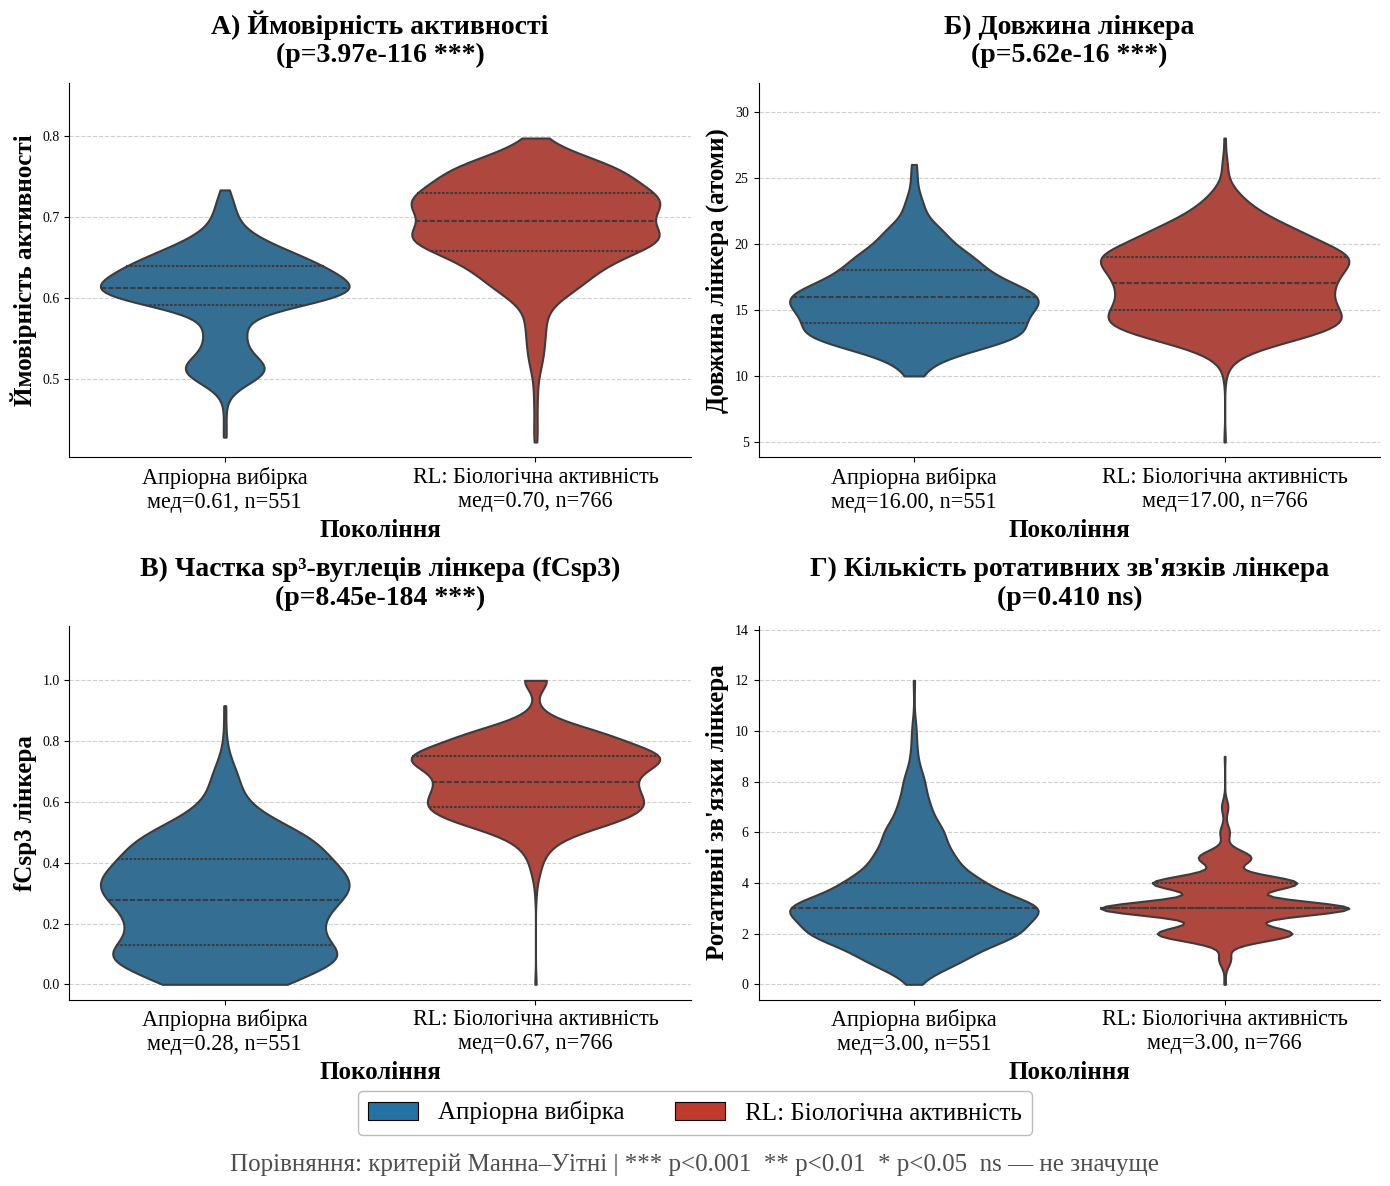

In [ ]:
MAGNITUDE_UA = {
    "negligible": "незначний",
    "small":      "малий",
    "medium":     "середній",
    "large":      "великий",
}

LINKER_ACTIVITY_GROUP = {
    "cols": ["Active_Probability", "Linker_Length", "Linker_fCsp3", "Linker_RotBonds"],
    "filename": "combined_activity_and_linkers_2x2.png"
}

def plot_2x2_violins(cols, filename, METRICS, stat_results):
    current_gen_order = ["Raw Prior", "PROTAC Active"]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12)) 
    axes_flat = axes.flatten()
    
    legend_patches = [
        patches.Patch(facecolor=PALETTE[g], edgecolor="black", linewidth=0.8, label=GEN_LABELS[g])
        for g in current_gen_order
    ]

    for idx, col in enumerate(cols):
        ax = axes_flat[idx]
        metric_cfg = METRICS[col]
        stat_res = stat_results[col]
        
        # 1. Filter data
        df_plot = metric_cfg["df"][metric_cfg["df"]["Generation"].isin(current_gen_order)].copy()
        n_by_gen = df_plot.groupby("Generation", observed=True)[col].count()
        
        # 2. Extract Stats
        pair_stat  = stat_res["pairs"][0]
        p_val      = pair_stat["p_raw"]
        stars      = pair_stat["stars"]
        cliffs_d   = pair_stat["cliffs_d"]    # ← нове
        magnitude  = pair_stat["magnitude"]   # ← нове
        p_text = f"p={p_val:.2e}" if p_val < 0.001 else f"p={p_val:.3f}"
        
        # 3. Violin Plot
        sns.violinplot(
            x="Generation", y=col, data=df_plot, order=current_gen_order,
            palette=PALETTE, hue="Generation", legend=False,
            cut=0, inner="quartile", linewidth=1.5, density_norm="width", ax=ax
        )

        # 4. Tick Labels
        tick_labels = []
        for gen in current_gen_order:
            arr = df_plot.loc[df_plot["Generation"] == gen, col].dropna()
            med = np.median(arr)
            n = n_by_gen[gen]
            fmt = ".2f" if col.lower() != "tpsa" else ".1f"
            tick_labels.append(f"{GEN_LABELS[gen]}\nмед={med:{fmt}}, n={n:,}")

        ax.set_xticks([0, 1])
        ax.set_xticklabels(tick_labels, fontsize=16, fontfamily="serif")
        
        # 5. Styling
        ax.set_title(
            f"{metric_cfg['label']}\n({p_text} {stars})",
            fontsize=20, fontweight="bold", pad=15
        )
        ax.set_xlabel("Покоління", fontsize=18, fontweight="bold")
        ax.set_ylabel(metric_cfg["ylabel"], fontsize=18, fontweight="bold")
        
        ax.set_axisbelow(True)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.spines[["top", "right"]].set_visible(False)

        # Y-axis Padding
        data_max, data_min = df_plot[col].max(), df_plot[col].min()
        range_val = data_max - data_min
        ax.set_ylim(bottom=data_min - range_val * 0.05, top=data_max + range_val * 0.18)

        # ── Cliff's Δ annotation ──────────────────────────────────  ← нове
        sign   = "+" if cliffs_d >= 0 else ""
        mag_ua = MAGNITUDE_UA[magnitude]
        ax.text(
            0.97, 0.97,
            f"Cliff's Δ = {sign}{cliffs_d:.3f}\n({mag_ua} ефект)",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=14, fontfamily="serif", color="#333333",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="#cccccc", alpha=0.85)
        )

    # ── Shared Legend ──
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.04), 
        ncol=2,
        prop={'size': 18, 'family': 'serif'},
        frameon=True,
        edgecolor="#aaaaaa"
    )

    # ── Footer ──                                                     ← оновлено
    fig.text(
        0.5, 0.02,
        "Критерій Манна–Уітні | *** p<0.001  ** p<0.01  * p<0.05  ns — не значуще"
        "   |   Cliff's Δ: <0.147 незначний · <0.330 малий · <0.474 середній · ≥0.474 великий",
        ha="center", fontsize=13, fontfamily="serif", color="#4E4E4E"
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1]) 
    plt.savefig(filename, dpi=400, bbox_inches="tight")
    plt.show()

plot_2x2_violins(
    cols=LINKER_ACTIVITY_GROUP["cols"],
    filename=LINKER_ACTIVITY_GROUP["filename"],
    METRICS=METRICS,
    stat_results=stat_results
)

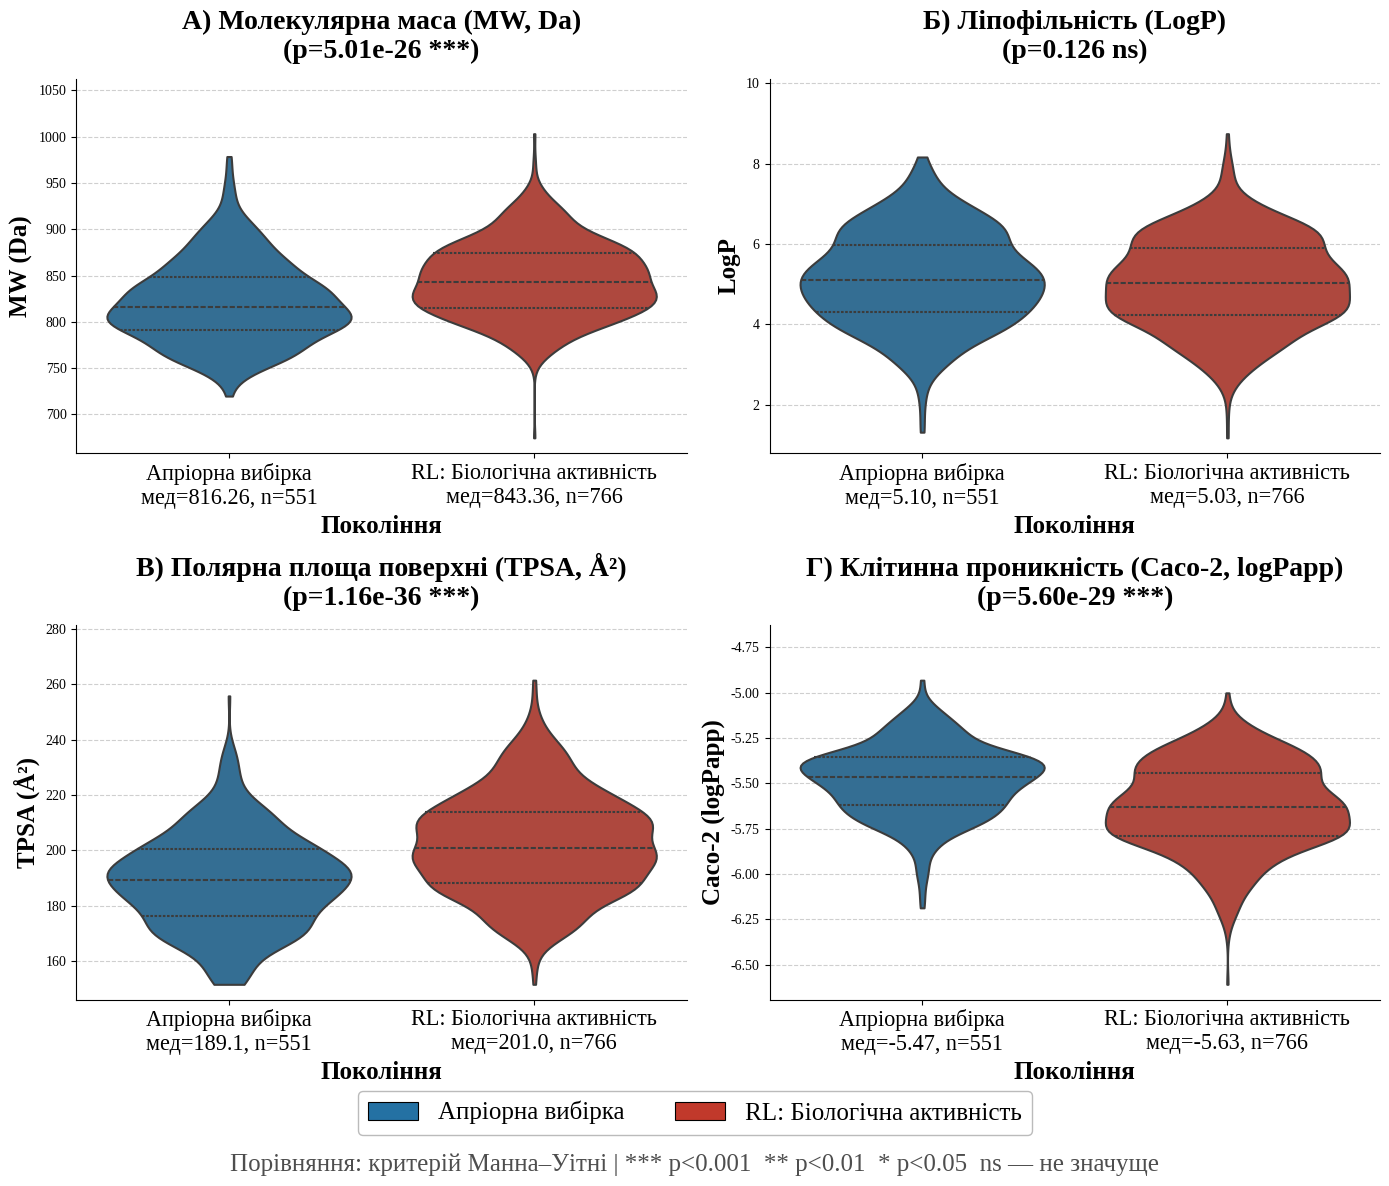

In [13]:
# ── Налаштування для 2x2 ──────────────────────────────────────────────────────
LINKER_ACTIVITY_GROUP = {
    "cols": ["molecular_weight", "logP", "tpsa", "Caco2_Wang"],
    "filename": "combined_mw_logp_tpsa_caco2_2x2.png"
}

def plot_2x2_violins(cols, filename, METRICS, stat_results):
    current_gen_order = ["Raw Prior", "PROTAC Active"]
    
    # Create 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 12)) 
    axes_flat = axes.flatten()
    
    legend_patches = [
        patches.Patch(facecolor=PALETTE[g], edgecolor="black", linewidth=0.8, label=GEN_LABELS[g])
        for g in current_gen_order
    ]

    for idx, col in enumerate(cols):
        ax = axes_flat[idx]
        metric_cfg = METRICS[col]
        stat_res = stat_results[col]
        
        # 1. Filter data
        df_plot = metric_cfg["df"][metric_cfg["df"]["Generation"].isin(current_gen_order)].copy()
        n_by_gen = df_plot.groupby("Generation", observed=True)[col].count()
        
        # 2. Extract Stats
        pair_stat = stat_res["pairs"][0]
        p_val = pair_stat["p_raw"]
        stars = pair_stat["stars"]
        p_text = f"p={p_val:.2e}" if p_val < 0.001 else f"p={p_val:.3f}"
        
        # 3. Violin Plot
        sns.violinplot(
            x="Generation", y=col, data=df_plot, order=current_gen_order,
            palette=PALETTE, hue="Generation", legend=False,
            cut=0, inner="quartile", linewidth=1.5, density_norm="width", ax=ax
        )

        # 4. Tick Labels
        tick_labels = []
        for gen in current_gen_order:
            arr = df_plot.loc[df_plot["Generation"] == gen, col].dropna()
            med = np.median(arr)
            n = n_by_gen[gen]
            fmt = ".2f" if col.lower() != "tpsa" else ".1f"
            tick_labels.append(f"{GEN_LABELS[gen]}\nмед={med:{fmt}}, n={n:,}")

        ax.set_xticks([0, 1])
        ax.set_xticklabels(tick_labels, fontsize=16, fontfamily="serif")
        
        # 5. Styling
        ax.set_title(f"{metric_cfg['label']}\n({p_text} {stars})", 
                     fontsize=20, fontweight="bold", pad=15)
        ax.set_xlabel("Покоління", fontsize=18, fontweight="bold")
        ax.set_ylabel(metric_cfg["ylabel"], fontsize=18, fontweight="bold")
        
        ax.set_axisbelow(True)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.spines[["top", "right"]].set_visible(False)

        # Y-axis Padding
        data_max, data_min = df_plot[col].max(), df_plot[col].min()
        range_val = data_max - data_min
        ax.set_ylim(bottom=data_min - range_val * 0.05, top=data_max + range_val * 0.18)

    # ── Shared Legend (Placed in the middle-bottom) ──
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.04), 
        ncol=2,
        prop={'size': 18, 'family': 'serif'},
        frameon=True,
        edgecolor="#aaaaaa"
    )

    # ── Footer ──
    fig.text(
        0.5, 0.02,
        "Порівняння: критерій Манна–Уітні | *** p<0.001  ** p<0.01  * p<0.05  ns — не значуще",
        ha="center", fontsize=18, fontfamily="serif", color="#4E4E4E"
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1]) 
    plt.savefig(filename, dpi=400, bbox_inches="tight")
    plt.show()

# Run the generation
plot_2x2_violins(
    cols=LINKER_ACTIVITY_GROUP["cols"],
    filename=LINKER_ACTIVITY_GROUP["filename"],
    METRICS=METRICS,
    stat_results=stat_results
)